In [3]:
import MDAnalysis as mda
import os
import tempfile
import gemmi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, shapiro, wilcoxon, spearmanr
import csv, math, statistics

**Boltz-2 VS AF3**

In [ ]:
df = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/comparisons/AF3_vs_all/rmsd_results_boltz_af3.csv")
df.head()


,Complex,Binder_RMSD,Target_RMSD
0,paulafcfranklin.synth_rosetta_1,0.560919,2.074347
1,merlettaia.seq0v3,4.469742,24.193096
2,minji.lee.459,1.093415,25.645309
3,spacecruiser42.d2_prompt_binder_t1.0_22,7.872086,23.696876
4,deepsatflow.6aru_final_chain_a_domain_3_l147_s...,0.253630,22.408480


In [6]:
binder_mean = df["Binder_RMSD"].mean()
target_mean = df["Target_RMSD"].mean()

print("Mean Binder RMSD:", binder_mean)
print("Mean Target RMSD:", target_mean)


Mean Binder RMSD: 4.134122367520099
Mean Target RMSD: 18.40671242529306


In [10]:
print("Median Binder RMSD:", df["Binder_RMSD"].median())
print("Median Target RMSD:", df["Target_RMSD"].median())


Median Binder RMSD: 1.5111807667744959
Median Target RMSD: 23.224381248477478


In [11]:
df_long = df.melt(
    value_vars=["Binder_RMSD", "Target_RMSD"],
    var_name="Chain",
    value_name="RMSD"
)


<function matplotlib.pyplot.show(close=None, block=None)>

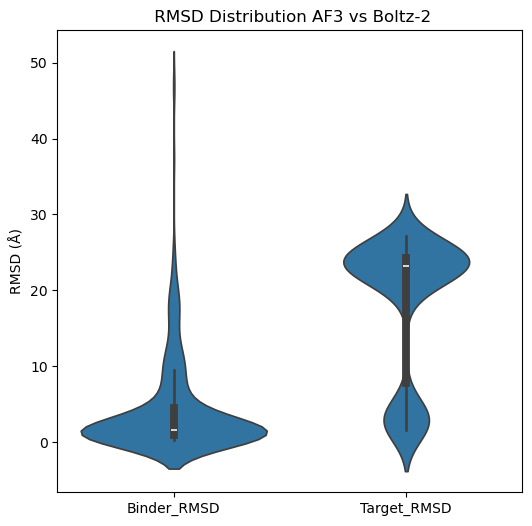

In [14]:
plt.figure(figsize=(6,6))

sns.violinplot(data=df_long,
               x="Chain",
               y="RMSD",
               inner="box"
               )

plt.title(" RMSD Distribution AF3 vs Boltz-2")
plt.ylabel("RMSD (Å)")
plt.xlabel("")
plt.show

Binder RMSD is lower → models agree more on binder

Target RMSD is higher → models disagree more on target orientation

Wide violin → high variability across complexes

Bimodal shape → two populations (stable vs unstable predictions)

In [15]:
def summarize(series):
    return {
        "mean": np.mean(series),
        "median": np.median(series),
        "std": np.std(series, ddof=1),   # sample SD
        "n": len(series)
    }

binder_stats = summarize(df["Binder_RMSD"])
target_stats = summarize(df["Target_RMSD"])

print("Binder:", binder_stats)
print("Target:", target_stats)


Binder: {'mean': np.float64(4.134122367520099), 'median': np.float64(1.5111807667744959), 'std': np.float64(6.1889579194701145), 'n': 402}
Target: {'mean': np.float64(18.40671242529306), 'median': np.float64(23.224381248477478), 'std': np.float64(9.107895074155962), 'n': 402}


In [18]:
t_stat, p_value = ttest_rel(
    df["Binder_RMSD"],
    df["Target_RMSD"]
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -28.899780783446626
p-value: 4.483045961185893e-100


In [20]:
diff = df["Binder_RMSD"] - df["Target_RMSD" \
""]
stat, p = shapiro(diff)
print("Shapiro p-value:", p)

Shapiro p-value: 7.034760760886988e-20


In [23]:
stat, p = wilcoxon(
    df["Binder_RMSD"],
    df["Target_RMSD"]
    )
print("wilcoxcon stat:", stat)
print("wilcoxcon p value:", p)

wilcoxcon stat: 2082.0
wilcoxcon p value: 4.992361553949842e-61


There's a statistically significant difference between binder and target RMSD

In [24]:
mean_diff = np.mean(diff)
std_diff = np.std(diff, ddof=1)

cohens_d = mean_diff / std_diff
print("Cohen's d:", cohens_d)


Cohen's d: -1.4413900571475988


Negative Cohen's d = Binder RMSD is smaller than target RMSD and the two models agree more on binder structure than on target structure

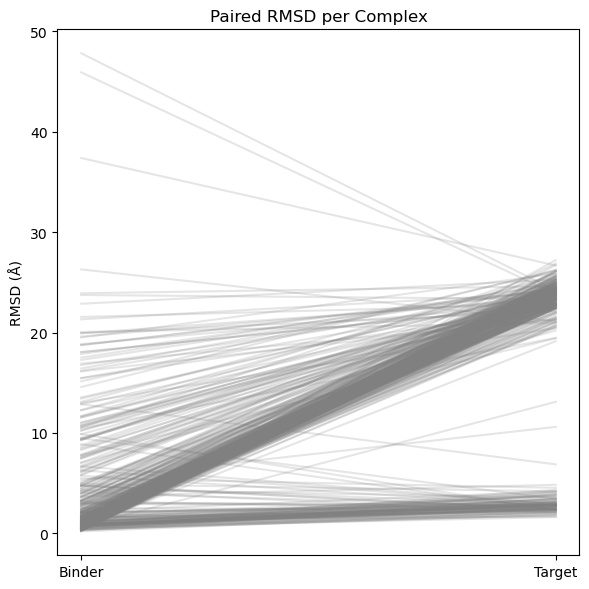

In [25]:
plt.figure(figsize=(6,6))

for i in range(len(df)):
    plt.plot(
        [1, 2],
        [df["Binder_RMSD"][i], df["Target_RMSD"][i]],
        color="gray",
        alpha=0.2
    )

plt.xticks([1, 2], ["Binder", "Target"])
plt.ylabel("RMSD (Å)")
plt.title("Paired RMSD per Complex")

plt.tight_layout()
plt.show()


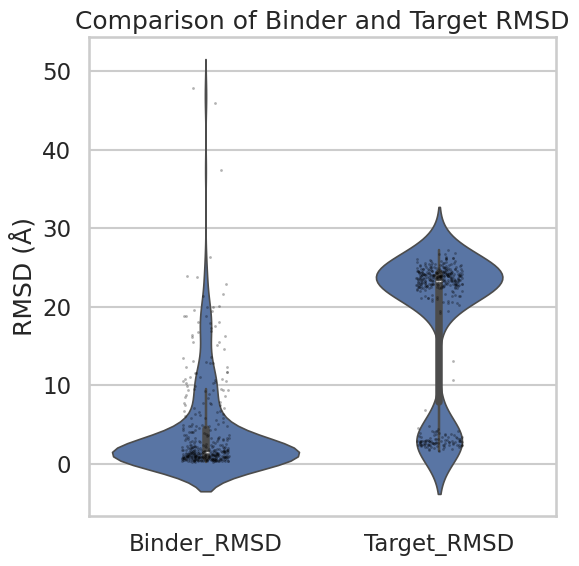

In [26]:
sns.set_theme(style="whitegrid", context="talk")

df_long = df.melt(
    value_vars=["Binder_RMSD", "Target_RMSD"],
    var_name="Chain",
    value_name="RMSD"
)

plt.figure(figsize=(6,6))

sns.violinplot(
    data=df_long,
    x="Chain",
    y="RMSD",
    inner="box",
    linewidth=1.2
)

sns.stripplot(
    data=df_long,
    x="Chain",
    y="RMSD",
    color="black",
    size=2,
    alpha=0.3
)

plt.ylabel("RMSD (Å)")
plt.xlabel("")
plt.title("Comparison of Binder and Target RMSD")

plt.tight_layout()
plt.savefig("rmsd_violin_plot.png", dpi=300)
plt.show()


<Axes: xlabel='Model', ylabel='Interface Size'>

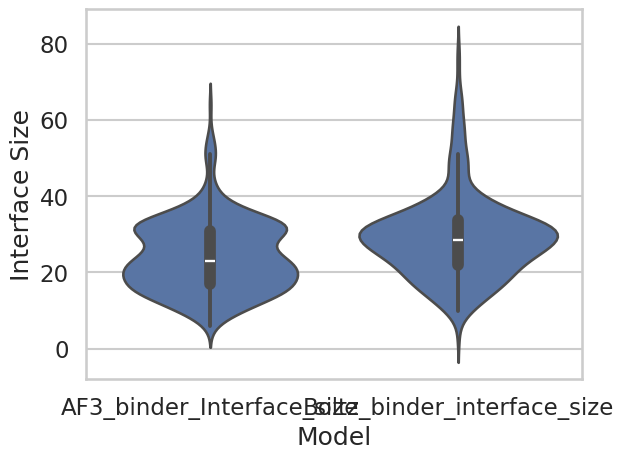

In [ ]:
df2 = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/comparisons/AF3_vs_all/interface_comparison_boltz_af3.csv")

df_long = df2.melt(
    value_vars=["AF3_binder_Interface_size", "Boltz_binder_interface_size"],
    var_name="Model",
    value_name="Interface Size"
)

sns.violinplot(data=df_long, x="Model", y="Interface Size", inner="box")


In [33]:
spearmanr(df2["AF3_binder_Interface_size"],
          df2["Boltz_binder_interface_size"])

SignificanceResult(statistic=np.float64(0.5289077857938526), pvalue=np.float64(2.354853335709128e-30))

<Axes: xlabel='Binder_Jaccard', ylabel='Count'>

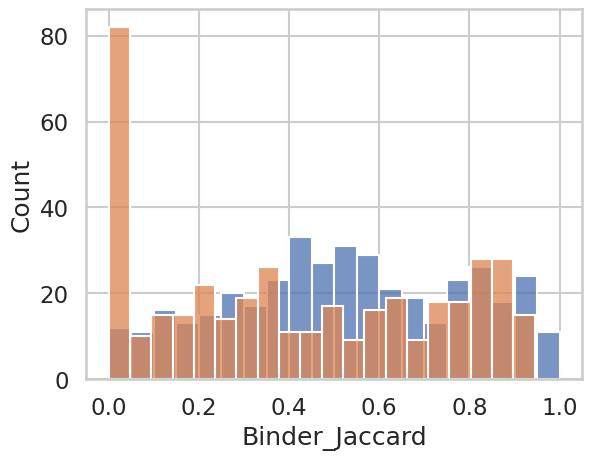

In [40]:
sns.histplot(df2["Binder_Jaccard"], bins=20)
sns.histplot(df2["target_jaccard"], bins=20)



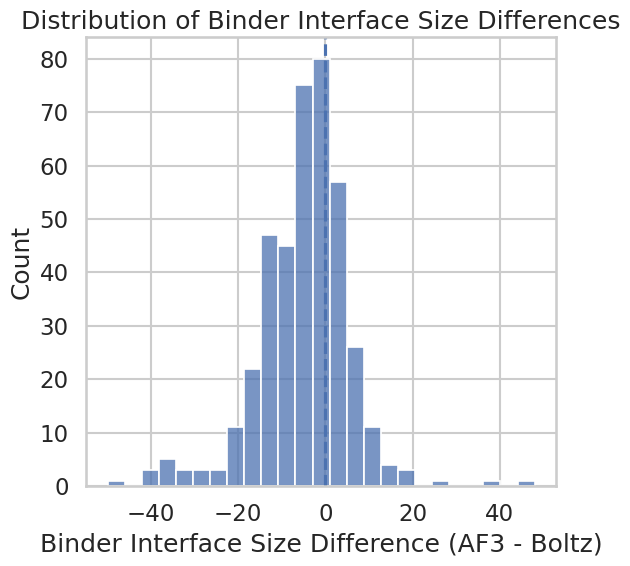

In [45]:
df2["Binder_size_diff"] = (
    df2["AF3_binder_Interface_size"]
    - df2["Boltz_binder_interface_size"]
)

plt.figure(figsize=(6,6))

sns.histplot(df2["Binder_size_diff"], bins=25)

plt.axvline(0, linestyle="--")  # zero reference line
plt.xlabel("Binder Interface Size Difference (AF3 - Boltz)")
plt.ylabel("Count")
plt.title("Distribution of Binder Interface Size Differences")

plt.tight_layout()
plt.show()


Symmetric around 0 → no systematic bias

Shifted right → AF3 larger

Shifted left → Boltz larger

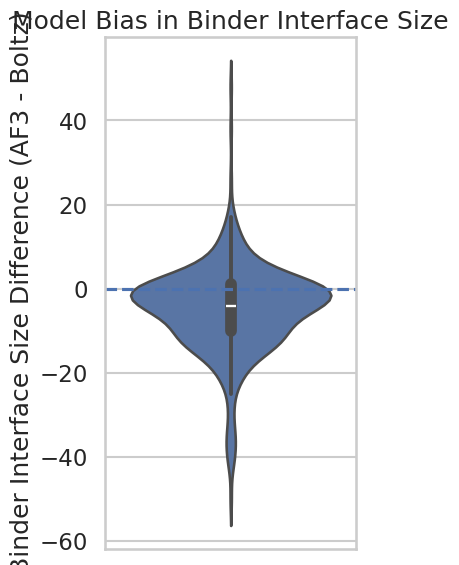

In [46]:
plt.figure(figsize=(4,6))

sns.violinplot(
    y=df2["Binder_size_diff"],
    inner="box"
)

plt.axhline(0, linestyle="--")
plt.ylabel("Binder Interface Size Difference (AF3 - Boltz)")
plt.title("Model Bias in Binder Interface Size")

plt.tight_layout()
plt.show()

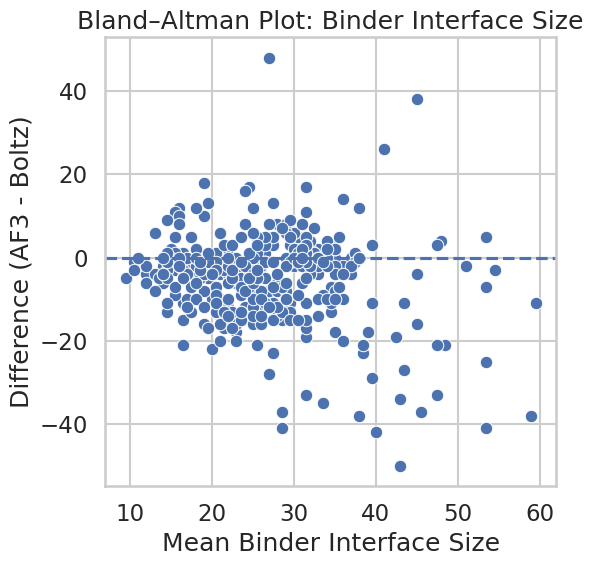

In [47]:
df2["Binder_mean_size"] = (
    df2["AF3_binder_Interface_size"]
    + df2["Boltz_binder_interface_size"]
) / 2

plt.figure(figsize=(6,6))

sns.scatterplot(
    x=df2["Binder_mean_size"],
    y=df2["Binder_size_diff"]
)

plt.axhline(0, linestyle="--")
plt.xlabel("Mean Binder Interface Size")
plt.ylabel("Difference (AF3 - Boltz)")
plt.title("Bland–Altman Plot: Binder Interface Size")

plt.tight_layout()
plt.show()


In [2]:

agreements = []

with open("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/comparisons/AF3_vs_all/contact_overlap_af3_boltz2.csv") as f:
    r = csv.DictReader(f)
    for row in r:
        af3 = int(row["af3_contacts"])
        b2  = int(row["boltz_contacts"])
        ovl = int(row["overlap_contacts"])

        denom = min(af3, b2)
        if denom > 0:
            agreements.append(ovl / denom)

overall_pct = 100 * np.median(agreements)
print(f"Overall agreement: {overall_pct:.1f}%")


Overall agreement: 29.9%


In [4]:
JACCARD_CSV = "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/comparisons/AF3_vs_all/interface_comparison_boltz_af3.csv"

def get_col (row, *names):
    for n in names:
        if n is None:
            continue
        for k, v in row.items():
            if k and k.strip().lower() == n.strip().lower():
                return v
    return None

binder_vals = []
target_vals = []
combined_vals = []

with open(JACCARD_CSV, newline="") as f:
    r = csv.DictReader(f)
    b_names={"Binder_Jaccard"}
    t_names={"target_jaccard"}  

    for row in r:
        # Get Jaccards
        bj_str = None
        tj_str = None
        for nm in b_names:
            if bj_str is None:
                bj_str = get_col(row, nm)
        for nm in t_names:
            if tj_str is None:
                tj_str = get_col(row, nm)

        try:
            bj = float(bj_str) if bj_str not in (None, "") else math.nan
            tj = float(tj_str) if tj_str not in (None, "") else math.nan
        except:
            bj, tj = math.nan, math.nan

        # Clamp to [0,1] if finite
        if math.isfinite(bj):
            bj = max(0.0, min(1.0, bj))
            binder_vals.append(bj)
        if math.isfinite(tj):
            tj = max(0.0, min(1.0, tj))
            target_vals.append(tj)

        if math.isfinite(bj) and math.isfinite(tj):
            combined_vals.append(0.5 * (bj + tj))


def pct(x): return 100.0 * x

if not combined_vals:
    raise ValueError("No valid Binder_Jaccard and Target_Jaccard pairs found.")

med_b = statistics.median(binder_vals) if binder_vals else float("nan")
med_t = statistics.median(target_vals) if target_vals else float("nan")
med_combined = statistics.median(combined_vals)

print(f"N complexes (with both binder+target): {len(combined_vals)}")
if math.isfinite(med_b):
    print(f"Median Binder Jaccard: {pct(med_b):.1f}%")
if math.isfinite(med_t):
    print(f"Median Target Jaccard: {pct(med_t):.1f}%")
print(f"Median Combined Jaccard: {pct(med_combined):.1f}%")



N complexes (with both binder+target): 402
Median Binder Jaccard: 50.8%
Median Target Jaccard: 37.4%
Median Combined Jaccard: 41.4%
